# Exploratory Data Analysis
Global Cybersecurity Threats (2015-2024) — Fast vs. Slow Resolution project

First working version, written without the Colab/reference material yet.
Will be revised with attribution comments once those are provided.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_PATH = Path("../data/raw/cybersecurity_threats.csv")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## 1. Load and inspect the raw data

In [2]:
df = pd.read_csv(RAW_PATH)
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)
print(df.shape)
df.head()

(3000, 10)


,country,year,attack_type,target_industry,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            3000 non-null   str    
 1   year                               3000 non-null   int64  
 2   attack_type                        3000 non-null   str    
 3   target_industry                    3000 non-null   str    
 4   financial_loss_in_million_         3000 non-null   float64
 5   number_of_affected_users           3000 non-null   int64  
 6   attack_source                      3000 non-null   str    
 7   security_vulnerability_type        3000 non-null   str    
 8   defense_mechanism_used             3000 non-null   str    
 9   incident_resolution_time_in_hours  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB


In [4]:
df.isnull().sum()

country                              0
year                                 0
attack_type                          0
target_industry                      0
financial_loss_in_million_           0
number_of_affected_users             0
attack_source                        0
security_vulnerability_type          0
defense_mechanism_used               0
incident_resolution_time_in_hours    0
dtype: int64

## 2. Class balance check — will Fast/Slow be roughly balanced?

In [5]:
median_time = df["incident_resolution_time_in_hours"].median()
print(f"Median resolution time: {median_time:.2f} hours")

df["resolution_class"] = (
    df["incident_resolution_time_in_hours"] >= median_time
).map({True: "Slow", False: "Fast"})

df["resolution_class"].value_counts()

Median resolution time: 37.00 hours


resolution_class
Slow    1501
Fast    1499
Name: count, dtype: int64

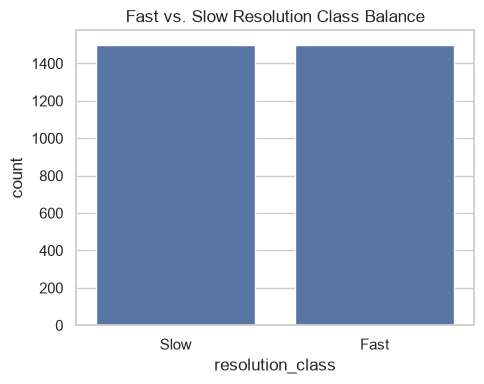

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="resolution_class")
plt.title("Fast vs. Slow Resolution Class Balance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png")
plt.show()

## 3. Average resolution time by defense mechanism
This is the core question for Option C — which defense mechanisms are
associated with faster containment?

In [7]:
avg_by_defense = (
    df.groupby("defense_mechanism_used")["incident_resolution_time_in_hours"]
    .mean()
    .sort_values()
)
avg_by_defense

defense_mechanism_used
Firewall              35.714530
Antivirus             36.573248
Encryption            36.589527
AI-based Detection    36.612350
VPN                   36.864379
Name: incident_resolution_time_in_hours, dtype: float64

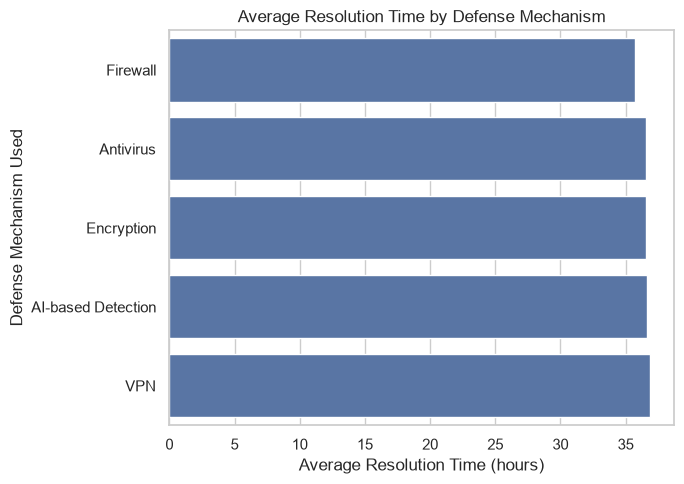

In [9]:
plt.figure(figsize=(7, 5))
sns.barplot(x=avg_by_defense.values, y=avg_by_defense.index, orient="h")
plt.xlabel("Average Resolution Time (hours)")
plt.ylabel("Defense Mechanism Used")
plt.title("Average Resolution Time by Defense Mechanism")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "avg_resolution_by_defense.png")
plt.show()

## 4. Fast/Slow ratio by defense mechanism

In [10]:
ratio_table = pd.crosstab(
    df["defense_mechanism_used"], df["resolution_class"], normalize="index"
)
ratio_table

resolution_class,Fast,Slow
defense_mechanism_used,,
AI-based Detection,0.500858,0.499142
Antivirus,0.501592,0.498408
Encryption,0.498311,0.501689
Firewall,0.524786,0.475214
VPN,0.473856,0.526144


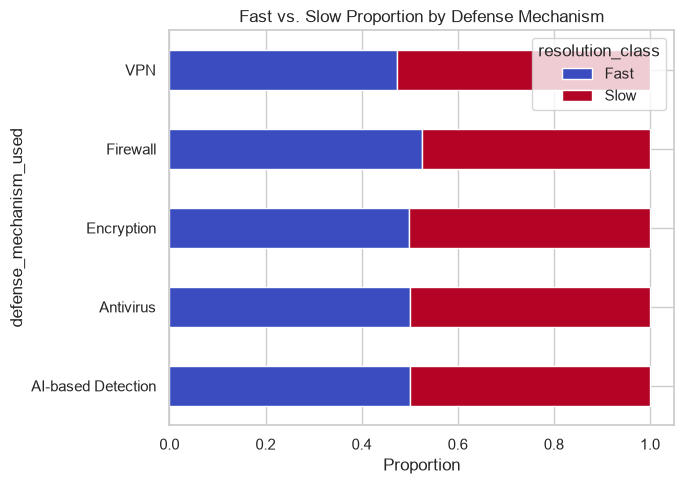

In [11]:
ratio_table.plot(kind="barh", stacked=True, figsize=(7, 5), colormap="coolwarm")
plt.xlabel("Proportion")
plt.title("Fast vs. Slow Proportion by Defense Mechanism")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fast_slow_ratio_by_defense.png")
plt.show()

## 5. Defense mechanism vs. attack type
Does the 'best' defense mechanism depend on the type of attack?

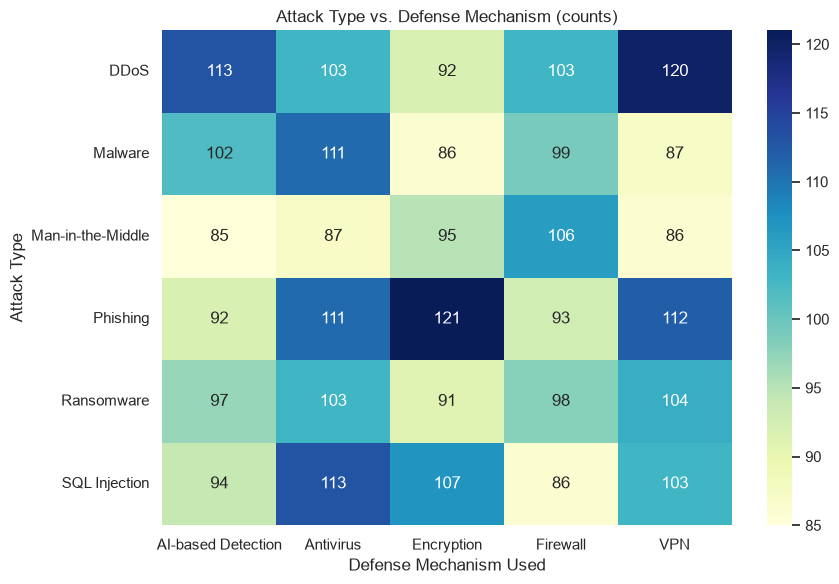

In [13]:
crosstab = pd.crosstab(df["attack_type"], df["defense_mechanism_used"])

plt.figure(figsize=(9, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Attack Type vs. Defense Mechanism (counts)")
plt.xlabel("Defense Mechanism Used")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "attack_type_vs_defense.png")
plt.show()

## 6. Notes / takeaways
_(fill in after running — e.g. which defense mechanism had the lowest
average resolution time, whether the effect holds across attack types,
anything surprising in the class balance)_